In [2]:
import os
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import optuna

ModuleNotFoundError: No module named 'catboost'

In [2]:
df = pd.read_csv("../../data/weatherData.csv")

In [3]:
df.head()

,location_id,date,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),apparent_temperature_max (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),daylight_duration (s),...,precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm),sunrise,sunset
0,0,1/1/2010,1,30.1,22.6,26.0,34.5,25.0,29.0,42220.20,...,0.0,0.0,0,12.2,27.4,19,20.92,4.61,06:22,18:05
1,0,1/2/2010,51,30.1,23.7,26.3,33.9,26.1,29.7,42225.71,...,0.1,0.1,1,13.0,27.0,24,17.71,3.91,06:22,18:06
2,0,1/3/2010,51,29.6,23.1,26.0,34.5,26.2,29.9,42231.68,...,0.6,0.6,3,12.3,27.4,17,17.76,3.66,06:22,18:06
3,0,1/4/2010,2,28.9,23.1,25.7,31.7,26.1,28.4,42238.11,...,0.0,0.0,0,17.0,34.6,357,16.50,3.75,06:23,18:07
4,0,1/5/2010,1,28.1,21.3,24.6,30.0,22.9,26.2,42244.99,...,0.0,0.0,0,18.7,37.1,353,23.61,5.00,06:23,18:07


In [4]:
df.columns

Index(['location_id', 'date', 'weather_code (wmo code)',
       'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
       'temperature_2m_mean (°C)', 'apparent_temperature_max (°C)',
       'apparent_temperature_min (°C)', 'apparent_temperature_mean (°C)',
       'daylight_duration (s)', 'sunshine_duration (s)',
       'precipitation_sum (mm)', 'rain_sum (mm)', 'precipitation_hours (h)',
       'wind_speed_10m_max (km/h)', 'wind_gusts_10m_max (km/h)',
       'wind_direction_10m_dominant (°)', 'shortwave_radiation_sum (MJ/m²)',
       'et0_fao_evapotranspiration (mm)', 'sunrise', 'sunset'],
      dtype='object')

In [5]:
# Parse date (coerce invalids), drop invalid dates and duplicates
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date']).drop_duplicates().reset_index(drop=True)

In [6]:
df['date']

0        2010-01-01
1        2010-01-02
2        2010-01-03
3        2010-01-04
4        2010-01-05
            ...    
142366   2024-06-04
142367   2024-06-05
142368   2024-06-06
142369   2024-06-07
142370   2024-06-08
Name: date, Length: 142371, dtype: datetime64[ns]

In [7]:
# Rename columns for consistency
rename_map = {
    'temperature_2m_mean (°C)': 'temp_mean',
    'precipitation_sum (mm)': 'precip_sum',
    'rain_sum (mm)': 'rain_sum',
    'wind_speed_10m_max (km/h)': 'wind_speed_max',
    'weather_code (wmo code)': 'weather_code'
}
df = df.rename(columns=rename_map)

In [8]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temperature_2m_max (°C)',
       'temperature_2m_min (°C)', 'temp_mean', 'apparent_temperature_max (°C)',
       'apparent_temperature_min (°C)', 'apparent_temperature_mean (°C)',
       'daylight_duration (s)', 'sunshine_duration (s)', 'precip_sum',
       'rain_sum', 'precipitation_hours (h)', 'wind_speed_max',
       'wind_gusts_10m_max (km/h)', 'wind_direction_10m_dominant (°)',
       'shortwave_radiation_sum (MJ/m²)', 'et0_fao_evapotranspiration (mm)',
       'sunrise', 'sunset'],
      dtype='object')

In [9]:
# Date Features 
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

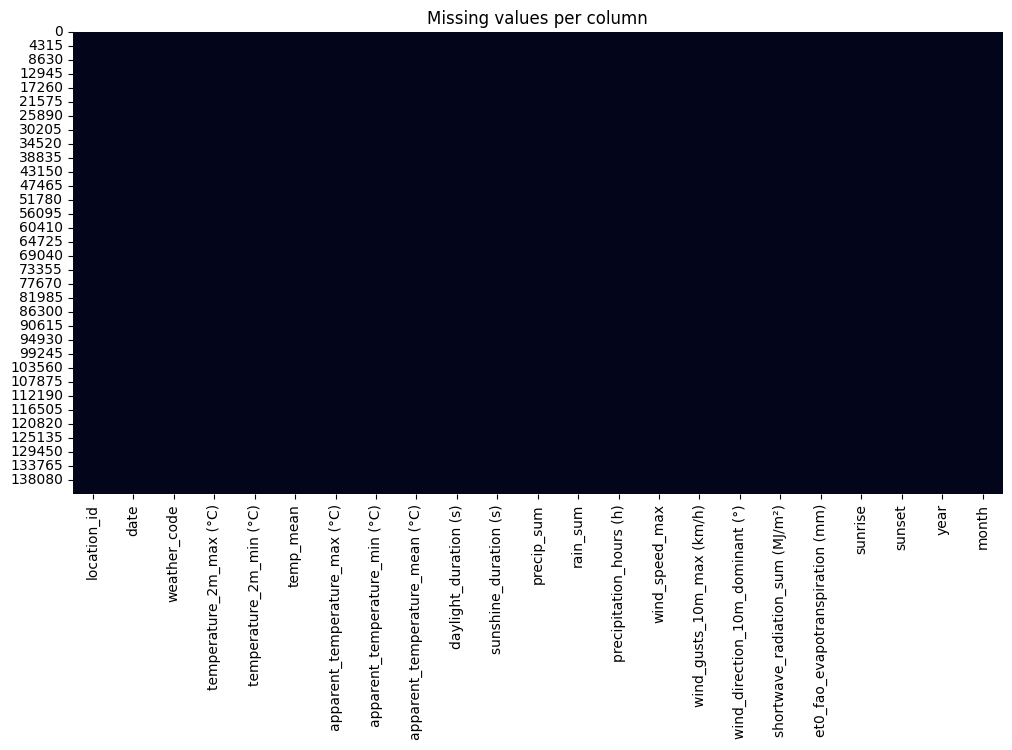

In [10]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing values per column")
plt.show()

In [34]:
# there are no missing values in the dataset

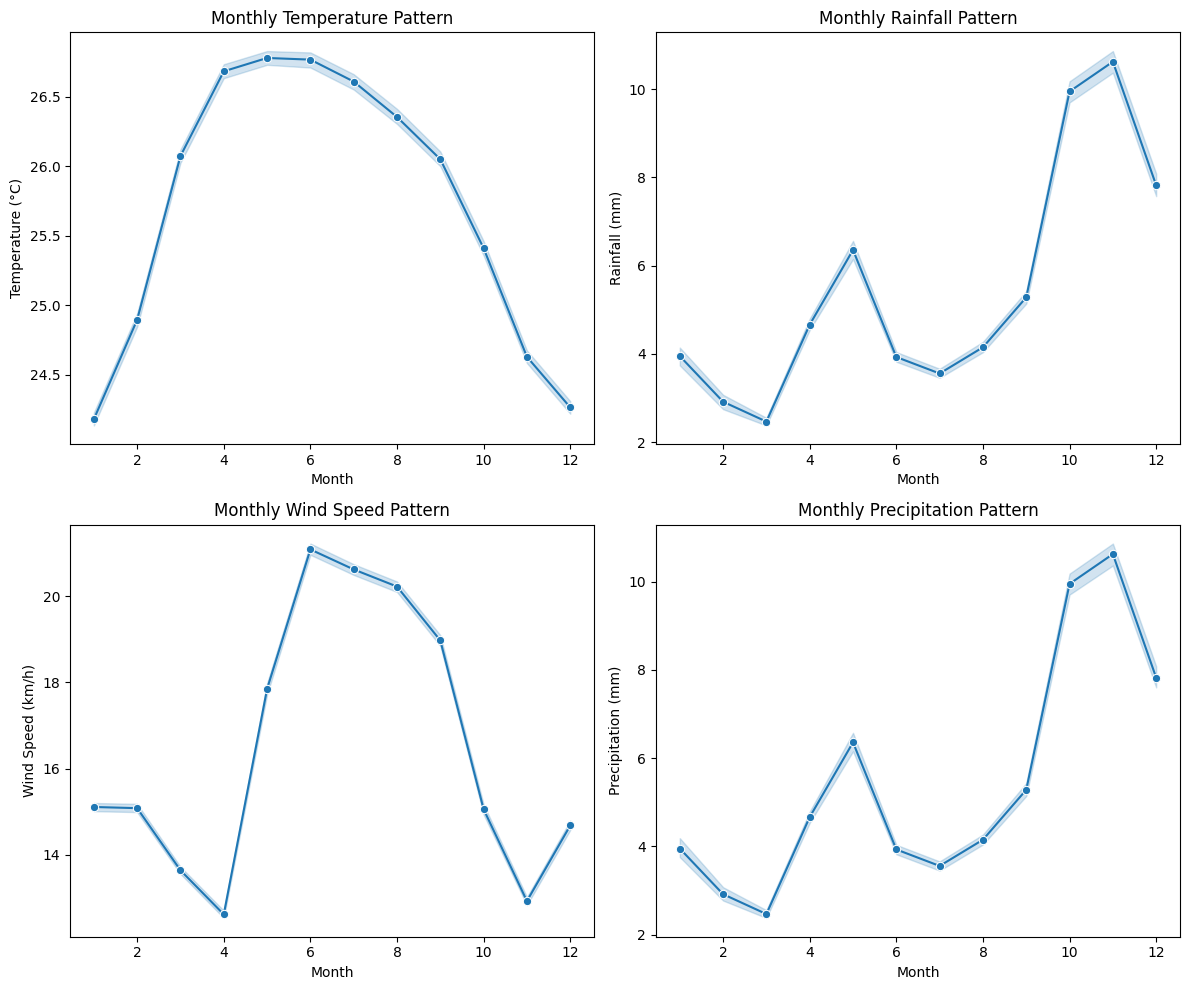

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

# Temperature
plt.subplot(2, 2, 1)
sns.lineplot(x="month", y="temp_mean", data=df, marker='o')
plt.title("Monthly Temperature Pattern")
plt.xlabel("Month")
plt.ylabel("Temperature (°C)")

# Rainfall
plt.subplot(2, 2, 2)
sns.lineplot(x="month", y="rain_sum", data=df, marker='o')
plt.title("Monthly Rainfall Pattern")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm)")

# Wind Speed
plt.subplot(2, 2, 3)
sns.lineplot(x="month", y="wind_speed_max", data=df, marker='o')
plt.title("Monthly Wind Speed Pattern")
plt.xlabel("Month")
plt.ylabel("Wind Speed (km/h)")

# Precipitation
plt.subplot(2, 2, 4)
sns.lineplot(x="month", y="precip_sum", data=df, marker='o')
plt.title("Monthly Precipitation Pattern")
plt.xlabel("Month")
plt.ylabel("Precipitation (mm)")

# Adjust layout
plt.tight_layout()
plt.show()


In [12]:
df.columns.tolist()

['location_id',
 'date',
 'weather_code',
 'temperature_2m_max (°C)',
 'temperature_2m_min (°C)',
 'temp_mean',
 'apparent_temperature_max (°C)',
 'apparent_temperature_min (°C)',
 'apparent_temperature_mean (°C)',
 'daylight_duration (s)',
 'sunshine_duration (s)',
 'precip_sum',
 'rain_sum',
 'precipitation_hours (h)',
 'wind_speed_max',
 'wind_gusts_10m_max (km/h)',
 'wind_direction_10m_dominant (°)',
 'shortwave_radiation_sum (MJ/m²)',
 'et0_fao_evapotranspiration (mm)',
 'sunrise',
 'sunset',
 'year',
 'month']

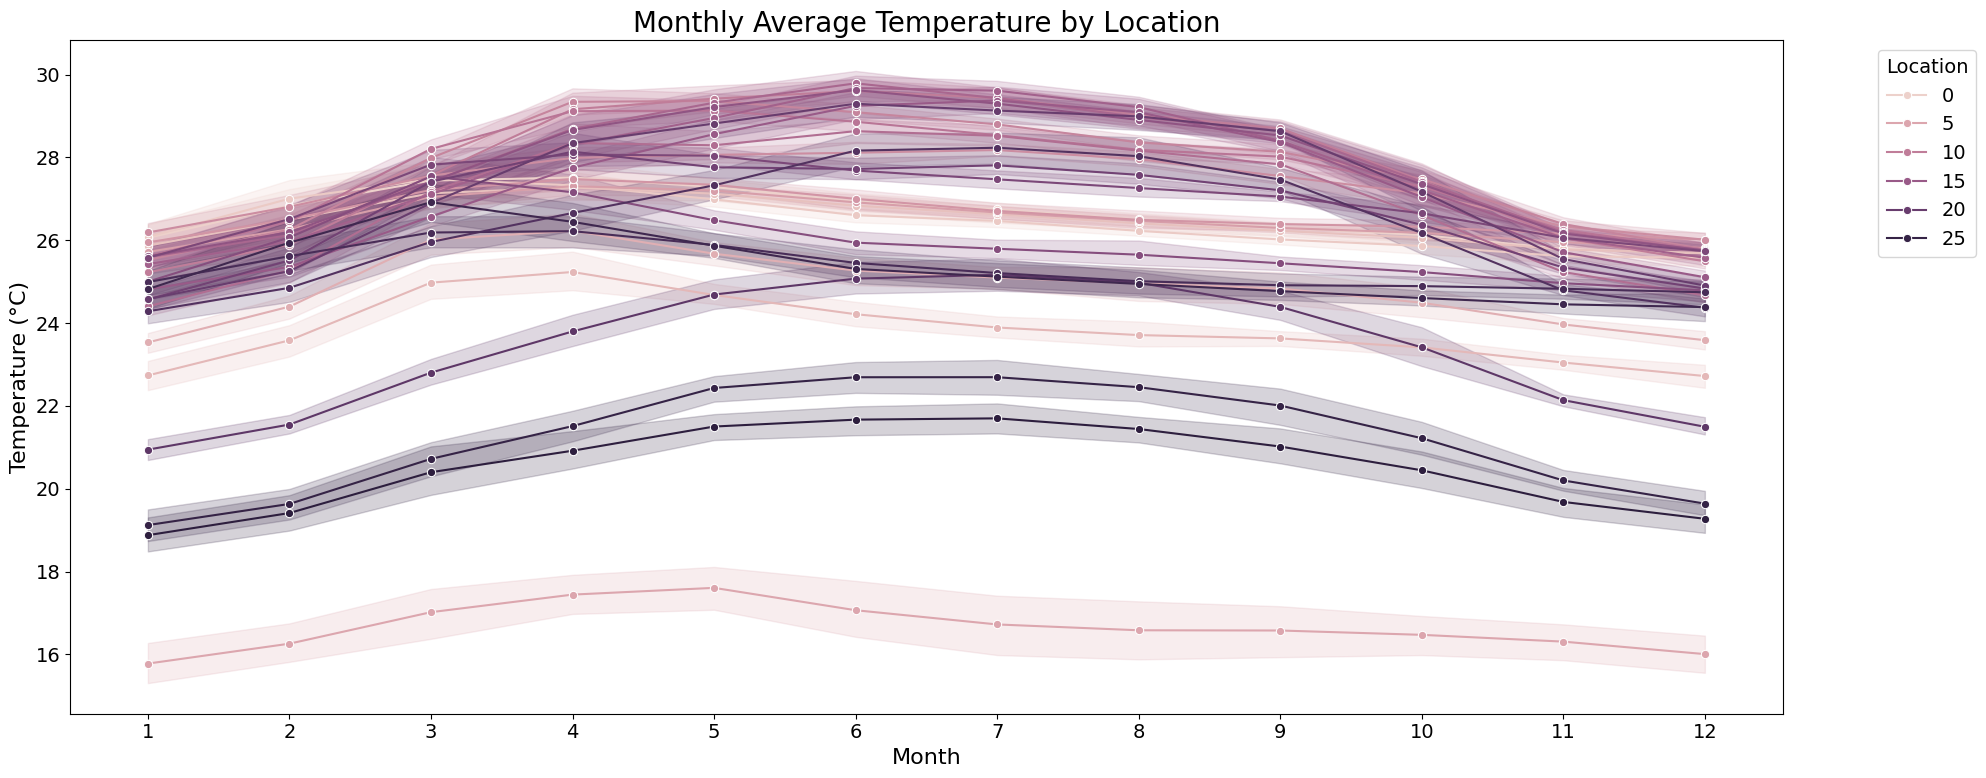

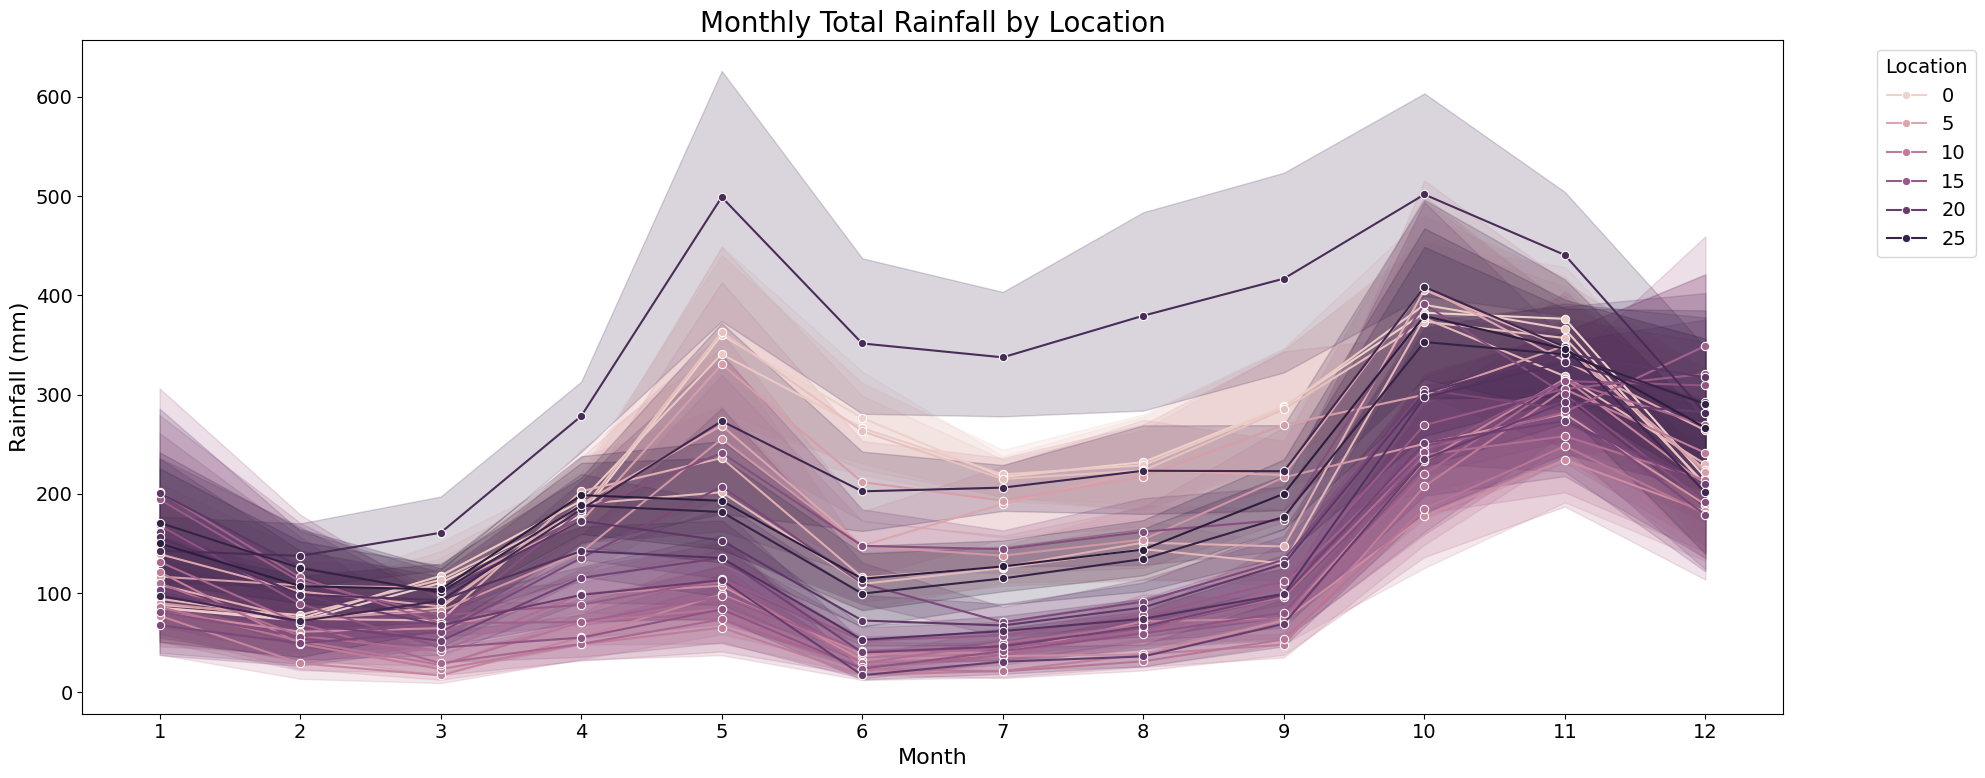

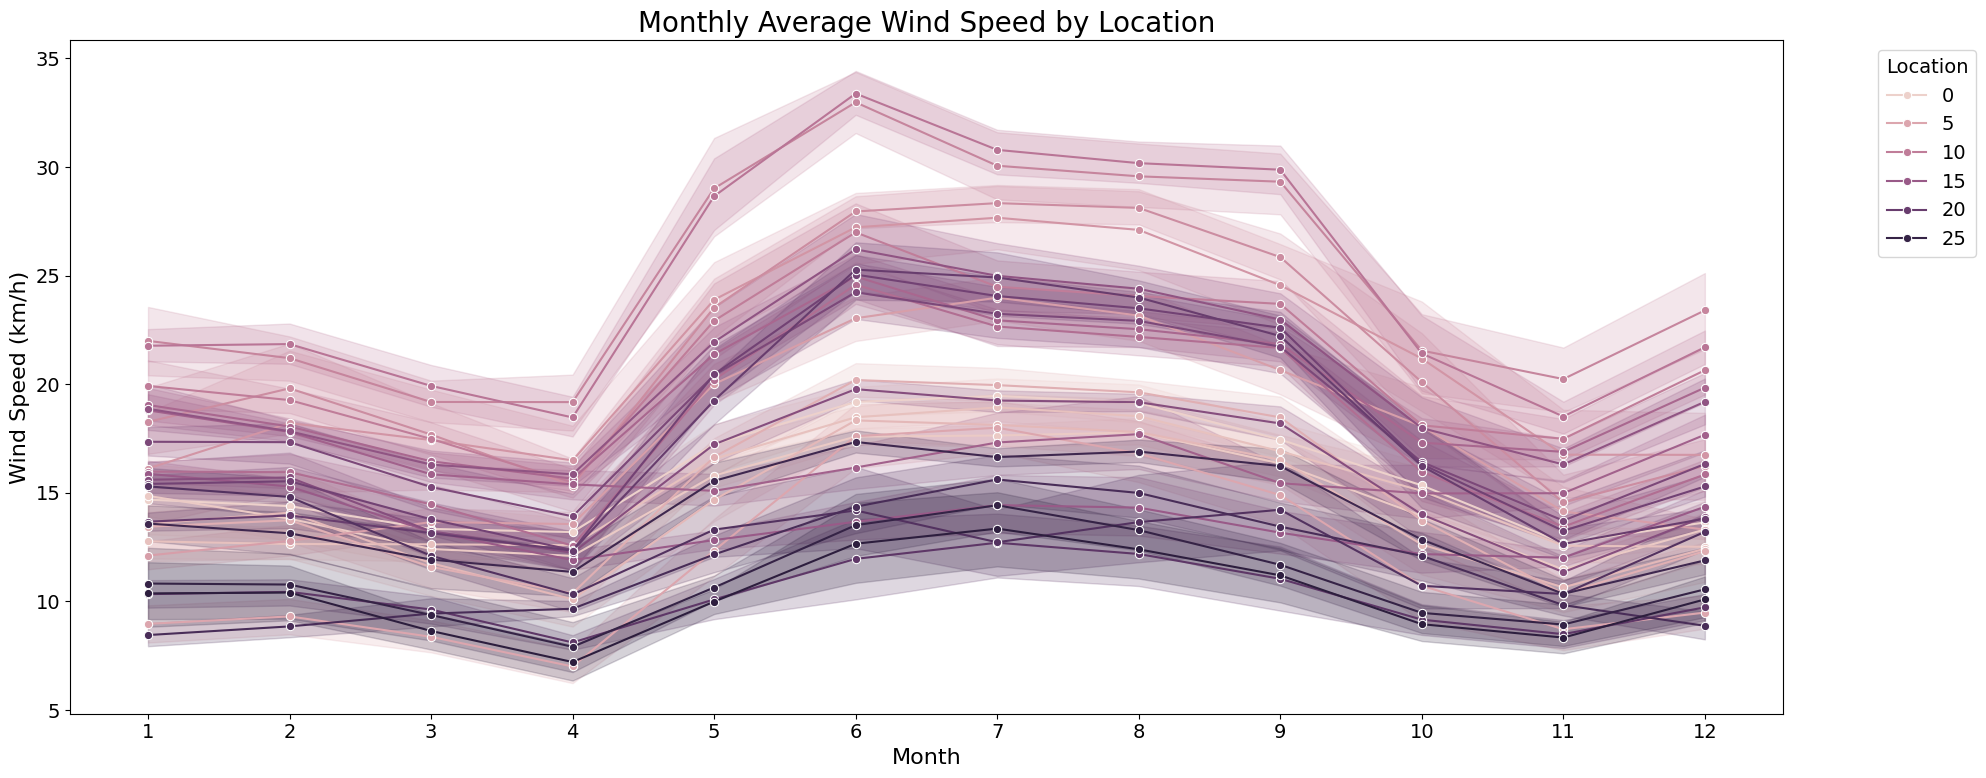

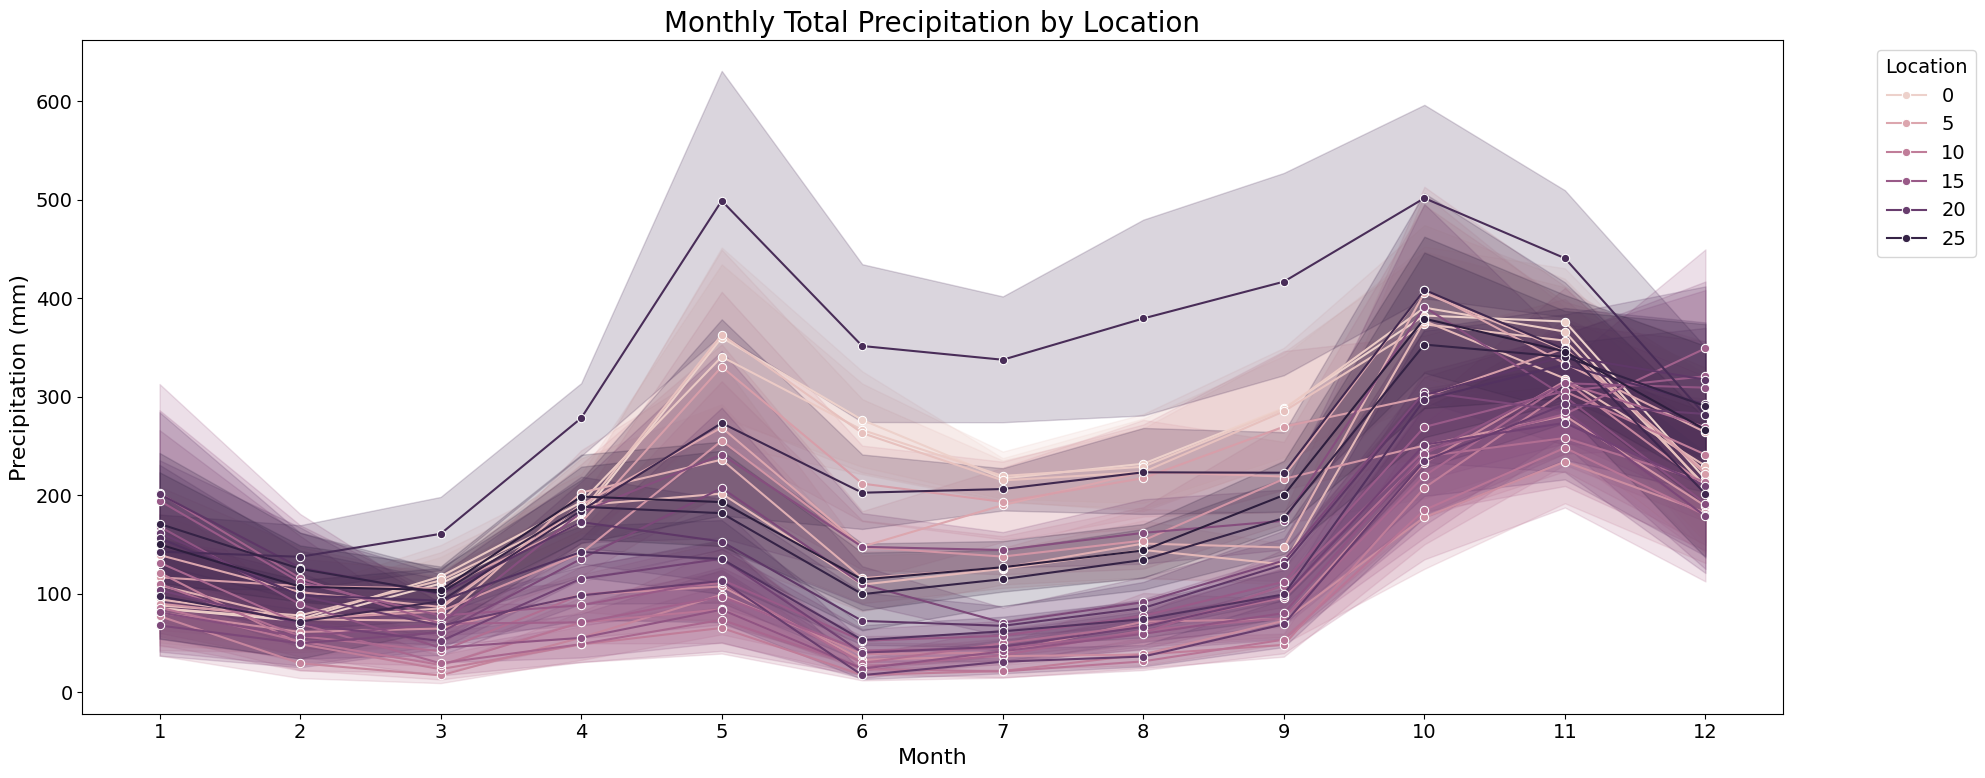

In [13]:
monthly_location_year = df.groupby(['location_id', 'year', 'month']).agg({
    'temp_mean': 'mean',
    'rain_sum': 'sum',
    'wind_speed_max': 'mean',
    'precip_sum': 'sum'
}).reset_index()

# Optional: rename for clarity (already mostly clear)
monthly_location_year.rename(columns={
    'temp_mean': 'temp_mean',
    'rain_sum': 'rain_sum',
    'wind_speed_max': 'wind_speed_max',
    'precip_sum': 'precip_sum'
}, inplace=True)
# Bigger figure and font settings
plt.rcParams.update({'font.size': 14})

# Temperature
plt.figure(figsize=(20, 8))  # bigger width & height
sns.lineplot(
    x='month', 
    y='temp_mean', 
    hue='location_id', 
    data=monthly_location_year, 
    marker='o'
)
plt.title("Monthly Average Temperature by Location", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Temperature (°C)", fontsize=16)
plt.xticks(range(1, 13))
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Rainfall
plt.figure(figsize=(20, 8))
sns.lineplot(
    x='month', 
    y='rain_sum', 
    hue='location_id', 
    data=monthly_location_year, 
    marker='o'
)
plt.title("Monthly Total Rainfall by Location", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Rainfall (mm)", fontsize=16)
plt.xticks(range(1, 13))
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Wind Speed
plt.figure(figsize=(20, 8))
sns.lineplot(
    x='month', 
    y='wind_speed_max', 
    hue='location_id', 
    data=monthly_location_year, 
    marker='o'
)
plt.title("Monthly Average Wind Speed by Location", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Wind Speed (km/h)", fontsize=16)
plt.xticks(range(1, 13))
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Precipitation
plt.figure(figsize=(20, 8))
sns.lineplot(
    x='month', 
    y='precip_sum', 
    hue='location_id', 
    data=monthly_location_year, 
    marker='o'
)
plt.title("Monthly Total Precipitation by Location", fontsize=20)
plt.xlabel("Month", fontsize=16)
plt.ylabel("Precipitation (mm)", fontsize=16)
plt.xticks(range(1, 13))
plt.legend(title='Location', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [14]:
numeric_cols = df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()
print(corr_matrix)

                                  location_id  weather_code  \
location_id                      1.000000e+00     -0.020001   
weather_code                    -2.000090e-02      1.000000   
temperature_2m_max (°C)          1.354173e-02     -0.240042   
temperature_2m_min (°C)         -2.012979e-01     -0.016407   
temp_mean                       -1.222578e-01     -0.161914   
apparent_temperature_max (°C)   -1.645424e-02     -0.074746   
apparent_temperature_min (°C)   -2.025316e-01      0.069722   
apparent_temperature_mean (°C)  -1.367046e-01     -0.007782   
daylight_duration (s)            2.617107e-04      0.042173   
sunshine_duration (s)           -1.711347e-02     -0.336387   
precip_sum                      -7.098242e-03      0.388749   
rain_sum                        -7.098242e-03      0.388749   
precipitation_hours (h)         -9.898134e-02      0.632714   
wind_speed_max                  -1.938643e-01     -0.175762   
wind_gusts_10m_max (km/h)       -1.235682e-01     -0.05

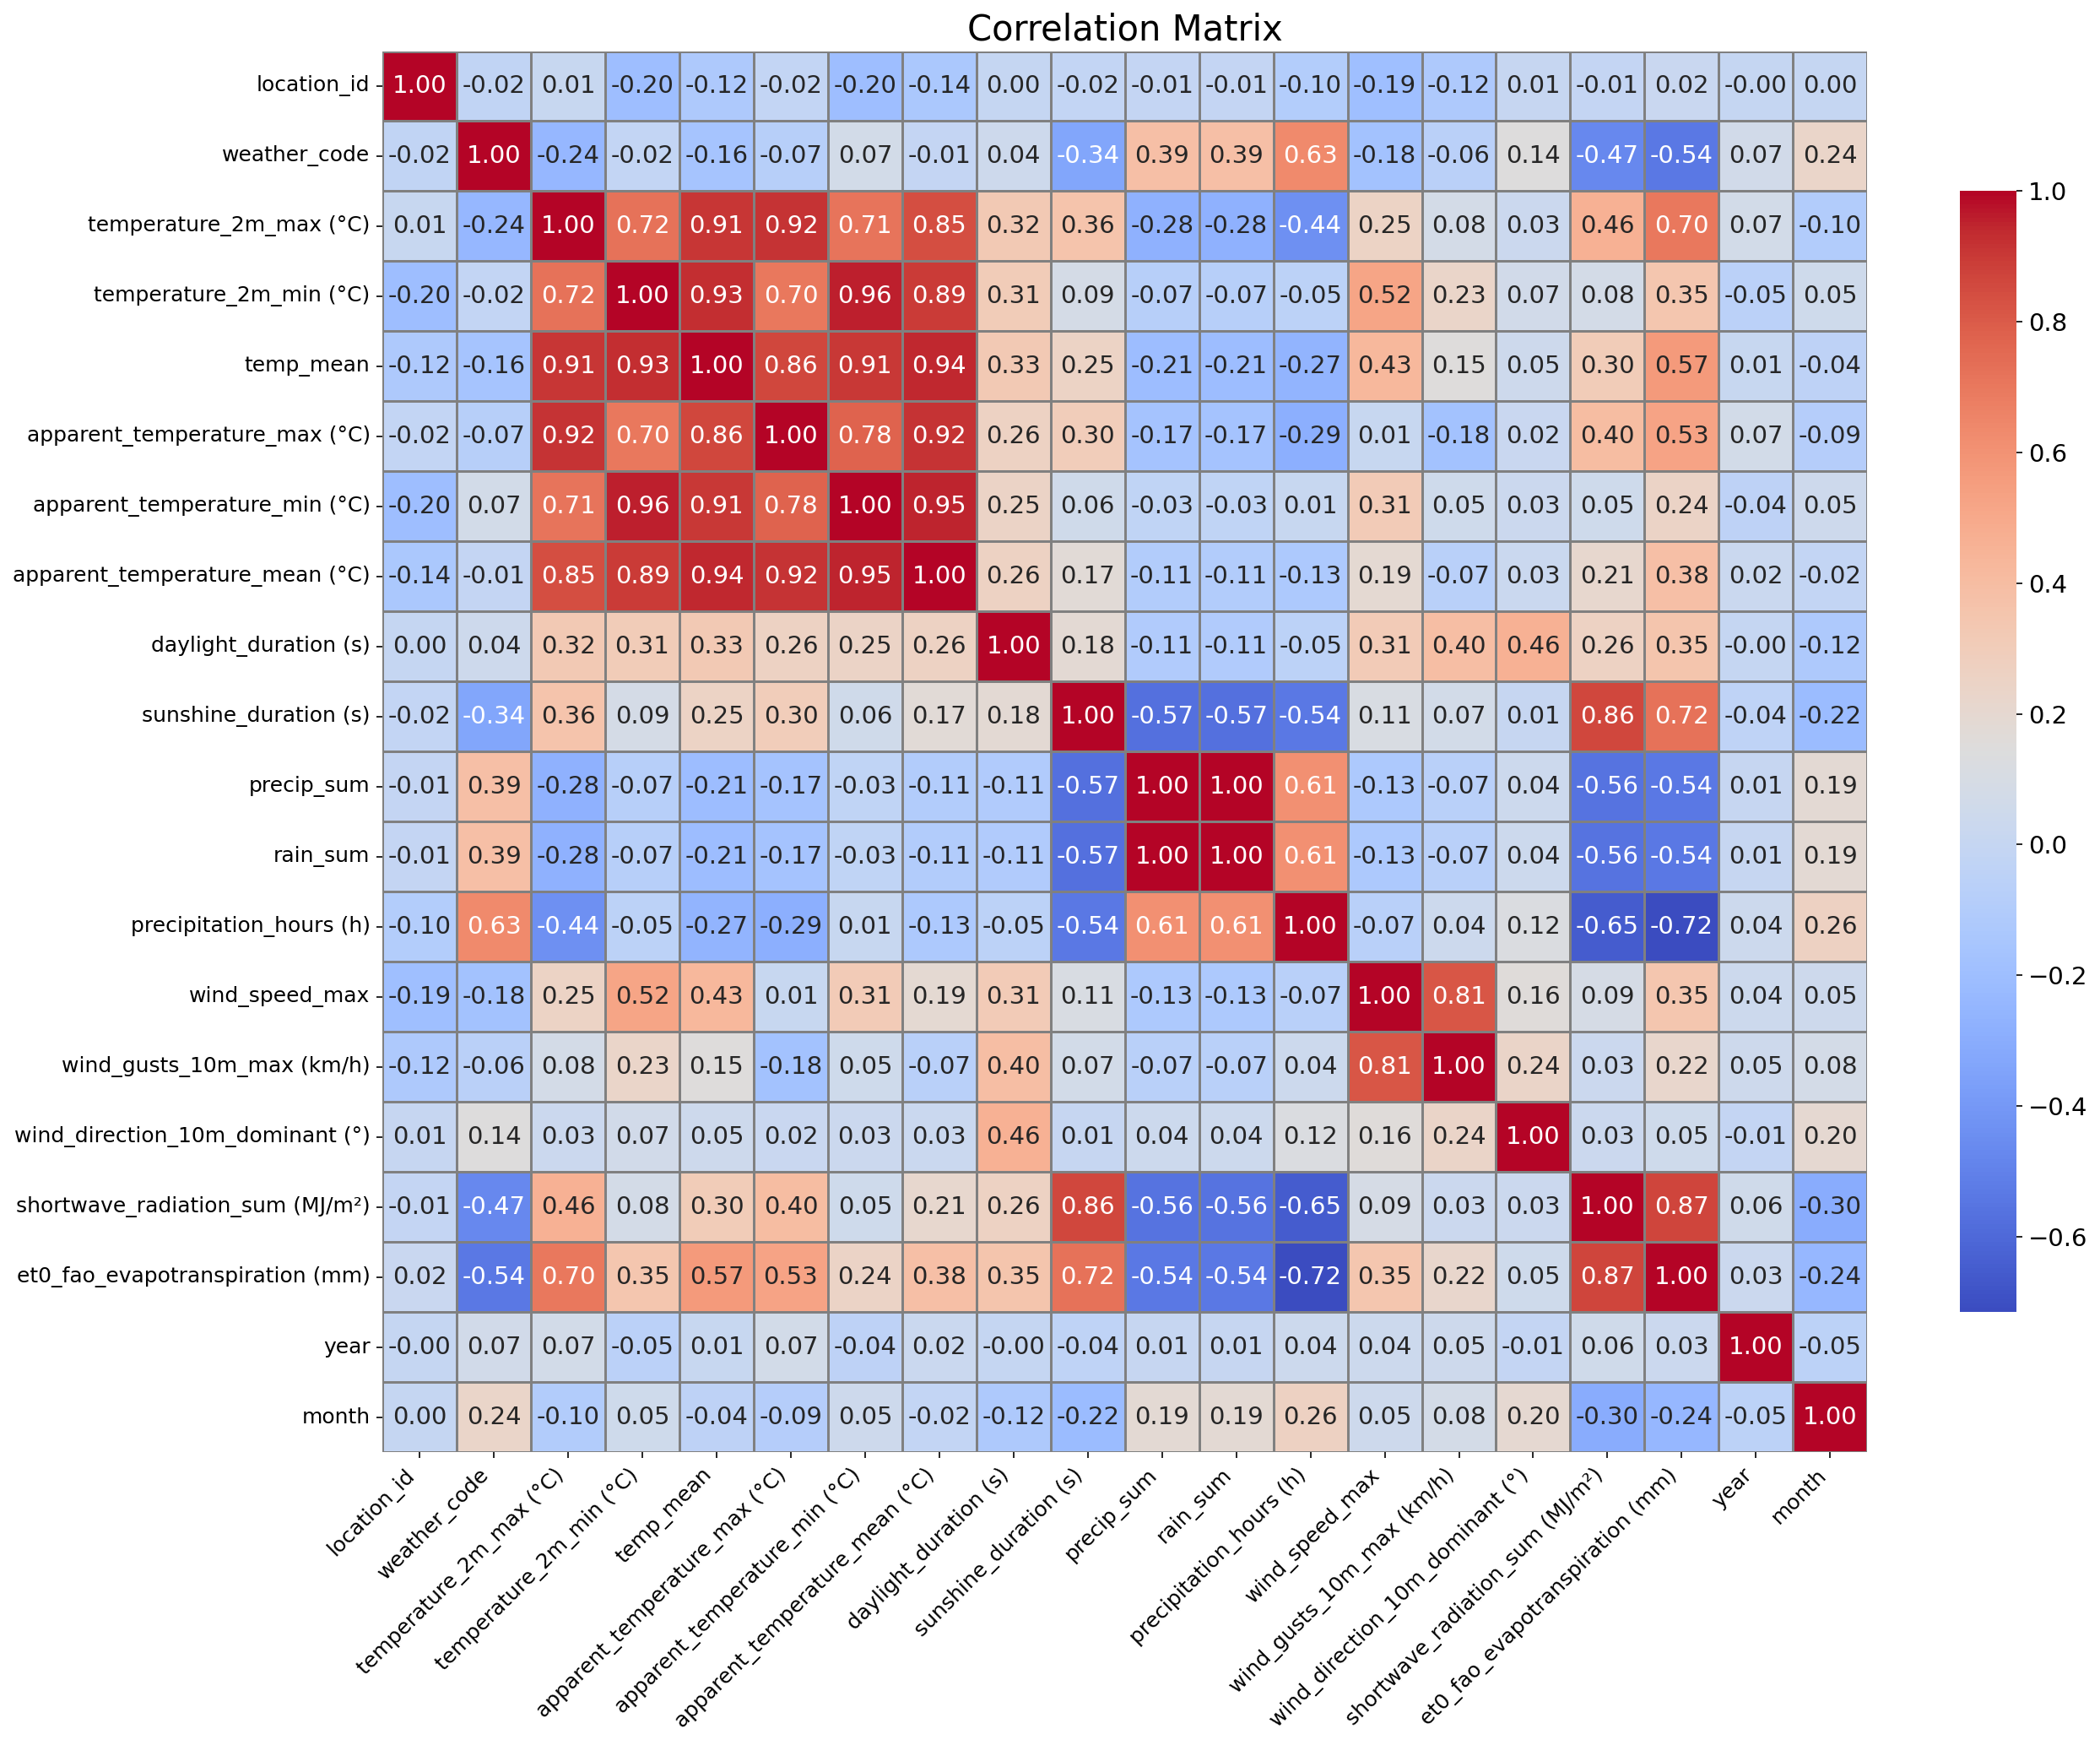

In [15]:
plt.figure(figsize=(18, 14), dpi=150)  # bigger figure + higher resolution
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            linewidths=0.5, linecolor='gray', cbar_kws={'shrink':0.8})
plt.title("Correlation Matrix", fontsize=20)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()


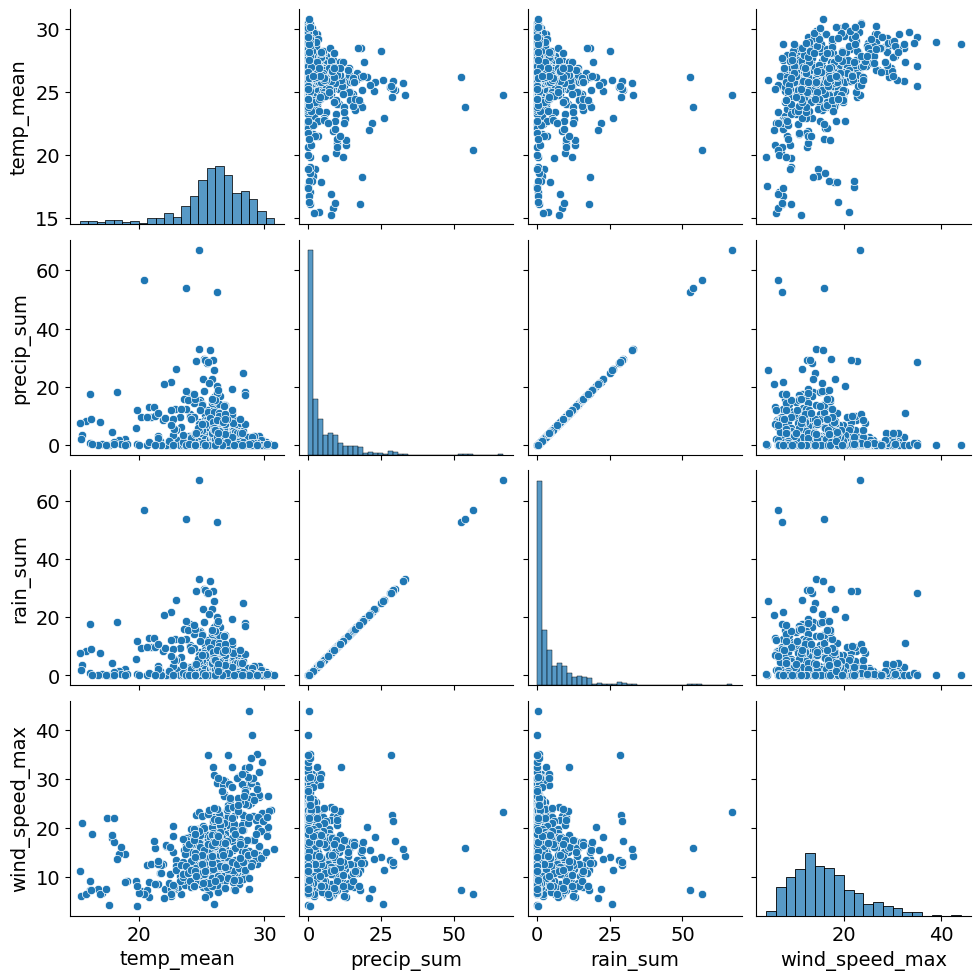

In [16]:
sample_df = df[['temp_mean', 'precip_sum', 'rain_sum', 'wind_speed_max']].sample(500, random_state=42)

sns.pairplot(sample_df)
plt.show()

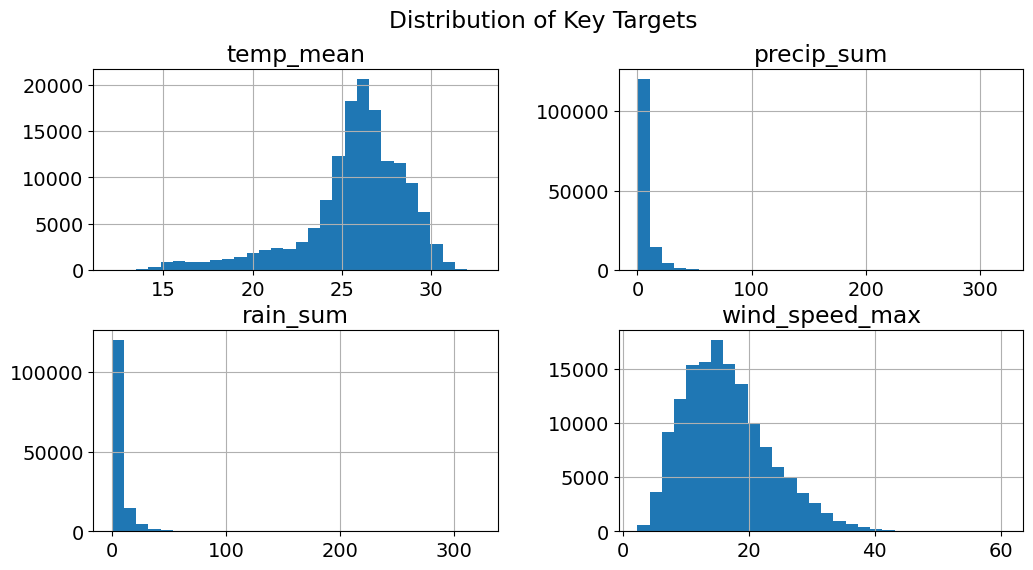

In [17]:
df[['temp_mean', 'precip_sum', 'rain_sum', 'wind_speed_max']].hist(bins=30, figsize=(12,6))
plt.suptitle("Distribution of Key Targets")
plt.show()

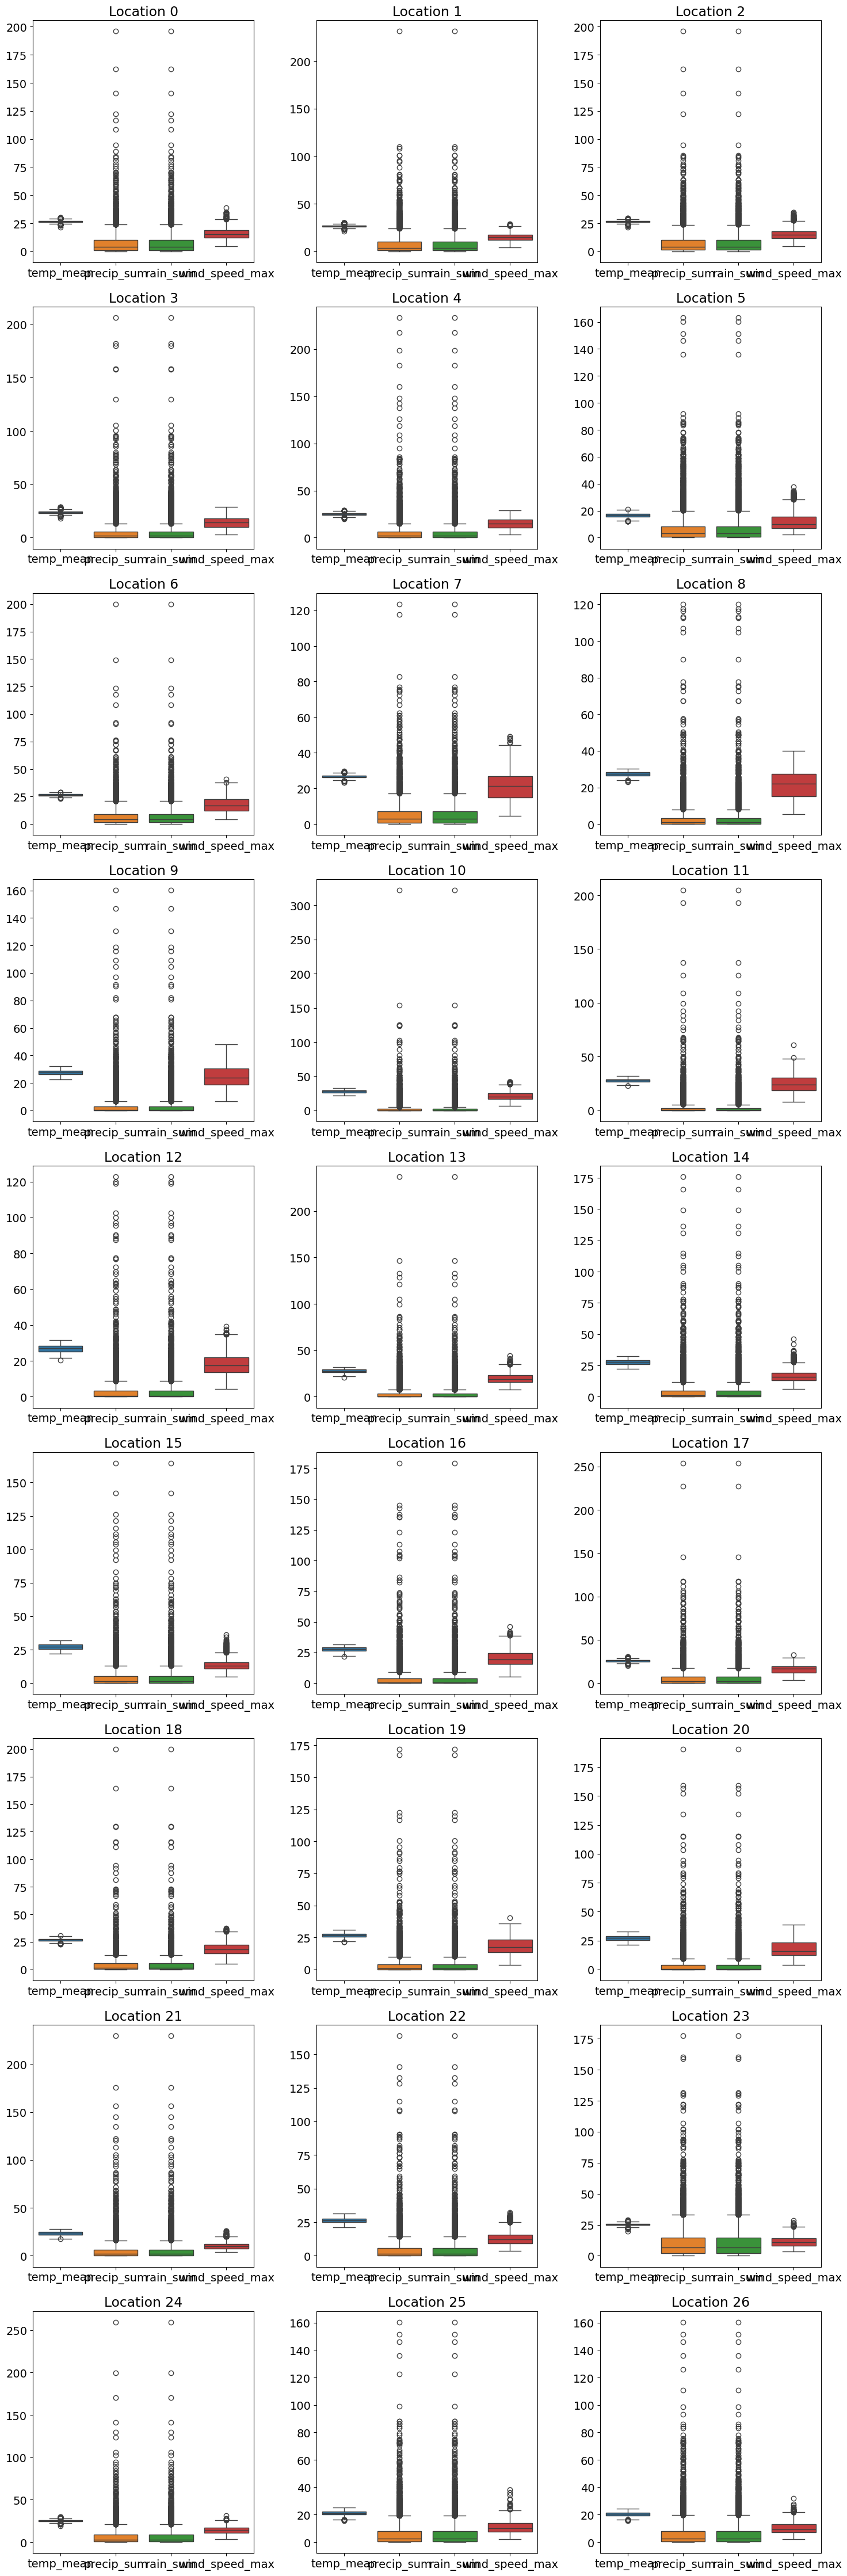

In [18]:
variables = ['temp_mean', 'precip_sum', 'rain_sum', 'wind_speed_max']
locations = df['location_id'].unique()
n_locations = len(locations)

# Define grid size for subplots
n_cols = 3  # you can adjust
n_rows = int(np.ceil(n_locations / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*5))
axes = axes.flatten()

for i, loc in enumerate(locations):
    city_df = df[df['location_id'] == loc]
    sns.boxplot(data=city_df[variables], ax=axes[i])
    axes[i].set_title(f'Location {loc}')

# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("all_locations_outliers_boxplot.png")
plt.show()

In [19]:
df.head(10)

,location_id,date,weather_code,temperature_2m_max (°C),temperature_2m_min (°C),temp_mean,apparent_temperature_max (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),daylight_duration (s),...,precipitation_hours (h),wind_speed_max,wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm),sunrise,sunset,year,month
0,0,2010-01-01,1,30.1,22.6,26.0,34.5,25.0,29.0,42220.20,...,0,12.2,27.4,19,20.92,4.61,06:22,18:05,2010,1
1,0,2010-01-02,51,30.1,23.7,26.3,33.9,26.1,29.7,42225.71,...,1,13.0,27.0,24,17.71,3.91,06:22,18:06,2010,1
2,0,2010-01-03,51,29.6,23.1,26.0,34.5,26.2,29.9,42231.68,...,3,12.3,27.4,17,17.76,3.66,06:22,18:06,2010,1
3,0,2010-01-04,2,28.9,23.1,25.7,31.7,26.1,28.4,42238.11,...,0,17.0,34.6,357,16.50,3.75,06:23,18:07,2010,1
4,0,2010-01-05,1,28.1,21.3,24.6,30.0,22.9,26.2,42244.99,...,0,18.7,37.1,353,23.61,5.00,06:23,18:07,2010,1
5,0,2010-01-06,1,28.8,21.3,24.9,31.2,22.8,26.3,42252.32,...,0,17.1,32.0,12,21.48,4.95,06:23,18:08,2010,1
6,0,2010-01-07,3,29.3,22.0,25.6,34.0,24.2,28.3,42260.19,...,0,13.5,25.6,10,19.38,4.38,06:24,18:08,2010,1
7,0,2010-01-08,53,28.4,23.4,25.6,32.2,26.1,29.0,42268.61,...,3,13.0,24.8,7,13.00,2.98,06:24,18:09,2010,1
8,0,2010-01-09,61,29.1,23.5,26.0,35.4,28.3,31.3,42277.55,...,5,11.5,31.7,163,16.89,3.34,06:24,18:09,2010,1
9,0,2010-01-10,51,30.1,22.6,26.2,35.8,27.1,31.2,42287.01,...,1,6.9,18.4,101,20.52,4.15,06:25,18:10,2010,1


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142371 entries, 0 to 142370
Data columns (total 23 columns):
 #   Column                           Non-Null Count   Dtype         
---  ------                           --------------   -----         
 0   location_id                      142371 non-null  int64         
 1   date                             142371 non-null  datetime64[ns]
 2   weather_code                     142371 non-null  int64         
 3   temperature_2m_max (°C)          142371 non-null  float64       
 4   temperature_2m_min (°C)          142371 non-null  float64       
 5   temp_mean                        142371 non-null  float64       
 6   apparent_temperature_max (°C)    142371 non-null  float64       
 7   apparent_temperature_min (°C)    142371 non-null  float64       
 8   apparent_temperature_mean (°C)   142371 non-null  float64       
 9   daylight_duration (s)            142371 non-null  float64       
 10  sunshine_duration (s)            142371 non-

In [21]:
df.describe()

,location_id,date,weather_code,temperature_2m_max (°C),temperature_2m_min (°C),temp_mean,apparent_temperature_max (°C),apparent_temperature_min (°C),apparent_temperature_mean (°C),daylight_duration (s),...,precip_sum,rain_sum,precipitation_hours (h),wind_speed_max,wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),shortwave_radiation_sum (MJ/m²),et0_fao_evapotranspiration (mm),year,month
count,142371.000000,142371,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,...,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000,142371.000000
mean,13.000000,2017-03-21 00:00:00,44.891586,29.295854,23.120601,25.730017,33.560477,26.362139,29.234477,43645.975220,...,5.442717,5.442717,7.337955,16.461730,37.118828,177.723567,18.933608,4.115296,2016.727290,6.421202
min,0.000000,2010-01-01 00:00:00,0.000000,14.100000,5.300000,12.100000,11.000000,2.000000,9.500000,41610.710000,...,0.000000,0.000000,0.000000,2.300000,9.400000,0.000000,1.120000,0.380000,2010.000000,1.000000
25%,6.000000,2013-08-11 00:00:00,51.000000,27.700000,22.000000,24.700000,31.400000,25.100000,27.900000,42607.350000,...,0.200000,0.200000,1.000000,11.400000,28.100000,78.000000,16.570000,3.350000,2013.000000,3.000000
50%,13.000000,2017-03-21 00:00:00,53.000000,29.300000,23.800000,26.200000,33.900000,27.600000,30.100000,43648.880000,...,1.800000,1.800000,6.000000,15.600000,35.300000,209.000000,19.710000,4.110000,2017.000000,6.000000
75%,20.000000,2020-10-29 00:00:00,61.000000,31.300000,25.200000,27.600000,36.300000,29.100000,31.600000,44685.075000,...,6.500000,6.500000,12.000000,20.400000,44.300000,247.000000,22.090000,4.890000,2020.000000,9.000000
max,26.000000,2024-06-08 00:00:00,65.000000,40.300000,30.300000,32.700000,46.100000,35.600000,37.700000,45676.100000,...,321.800000,321.800000,24.000000,60.700000,123.500000,360.000000,29.400000,8.450000,2024.000000,12.000000
std,7.788908,NaN,22.840879,3.352774,3.165760,2.954064,4.183799,4.196010,3.837440,1099.470021,...,10.286371,10.286371,6.861958,6.828743,11.676963,95.393165,4.398970,1.179600,4.172428,3.454946


In [22]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temperature_2m_max (°C)',
       'temperature_2m_min (°C)', 'temp_mean', 'apparent_temperature_max (°C)',
       'apparent_temperature_min (°C)', 'apparent_temperature_mean (°C)',
       'daylight_duration (s)', 'sunshine_duration (s)', 'precip_sum',
       'rain_sum', 'precipitation_hours (h)', 'wind_speed_max',
       'wind_gusts_10m_max (km/h)', 'wind_direction_10m_dominant (°)',
       'shortwave_radiation_sum (MJ/m²)', 'et0_fao_evapotranspiration (mm)',
       'sunrise', 'sunset', 'year', 'month'],
      dtype='object')

In [23]:
# Drop unwanted columns
drop_cols = [
    'precipitation_hours (h)',"daylight_duration (s)",
    'wind_gusts_10m_max (km/h)',
    'wind_direction_10m_dominant (°)',
    'shortwave_radiation_sum (MJ/m²)',
    'et0_fao_evapotranspiration (mm)',
    'sunrise', 'sunset',
    'temperature_2m_max (°C)', 'temperature_2m_min (°C)',
    'apparent_temperature_max (°C)', 'apparent_temperature_min (°C)',
    'apparent_temperature_mean (°C)', 'sunshine_duration (s)'
]
df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True, errors='ignore')

In [24]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temp_mean', 'precip_sum',
       'rain_sum', 'wind_speed_max', 'year', 'month'],
      dtype='object')

In [25]:
df.head()

,location_id,date,weather_code,temp_mean,precip_sum,rain_sum,wind_speed_max,year,month
0,0,2010-01-01,1,26.0,0.0,0.0,12.2,2010,1
1,0,2010-01-02,51,26.3,0.1,0.1,13.0,2010,1
2,0,2010-01-03,51,26.0,0.6,0.6,12.3,2010,1
3,0,2010-01-04,2,25.7,0.0,0.0,17.0,2010,1
4,0,2010-01-05,1,24.6,0.0,0.0,18.7,2010,1


In [26]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temp_mean', 'precip_sum',
       'rain_sum', 'wind_speed_max', 'year', 'month'],
      dtype='object')

# feature engineering


In [27]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['dayofyear'] = df['date'].dt.dayofyear
df['weekday'] = df['date'].dt.weekday  # Monday=0

# Cyclic encoding for dayofyear, month, weekday
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['weekday_sin'] = np.sin(2 * np.pi * df['weekday'] / 7)
df['weekday_cos'] = np.cos(2 * np.pi * df['weekday'] / 7)

In [28]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temp_mean', 'precip_sum',
       'rain_sum', 'wind_speed_max', 'year', 'month', 'day', 'dayofyear',
       'weekday', 'dayofyear_sin', 'dayofyear_cos', 'month_sin', 'month_cos',
       'weekday_sin', 'weekday_cos'],
      dtype='object')

In [29]:
# Historical Aggregates
# Compute historical mean for each target per location + dayofyear
targets = ['temp_mean', 'rain_sum', 'precip_sum', 'wind_speed_max']
for target in targets:
    hist = df.groupby(['location_id', 'dayofyear'])[target].mean().reset_index()
    hist.rename(columns={target: f'{target}_hist'}, inplace=True)
    df = df.merge(hist, on=['location_id', 'dayofyear'], how='left')

In [30]:
df.columns

Index(['location_id', 'date', 'weather_code', 'temp_mean', 'precip_sum',
       'rain_sum', 'wind_speed_max', 'year', 'month', 'day', 'dayofyear',
       'weekday', 'dayofyear_sin', 'dayofyear_cos', 'month_sin', 'month_cos',
       'weekday_sin', 'weekday_cos', 'temp_mean_hist', 'rain_sum_hist',
       'precip_sum_hist', 'wind_speed_max_hist'],
      dtype='object')

In [31]:
# Features
features = [
    'location_id', 'weather_code',
    'month_sin', 'month_cos',
    'weekday_sin', 'weekday_cos',
    'dayofyear_sin', 'dayofyear_cos',
    'temp_mean_hist', 'rain_sum_hist', 'precip_sum_hist', 'wind_speed_max_hist'
]



In [32]:
# Target 
cat_features = ['location_id', 'weather_code']
y_targets = ['rain_sum', 'precip_sum', 'temp_mean', 'wind_speed_max']


In [33]:
X = df[features]
y = df[y_targets]

In [34]:
X.columns

Index(['location_id', 'weather_code', 'month_sin', 'month_cos', 'weekday_sin',
       'weekday_cos', 'dayofyear_sin', 'dayofyear_cos', 'temp_mean_hist',
       'rain_sum_hist', 'precip_sum_hist', 'wind_speed_max_hist'],
      dtype='object')

In [35]:
y

,rain_sum,precip_sum,temp_mean,wind_speed_max
0,0.0,0.0,26.0,12.2
1,0.1,0.1,26.3,13.0
2,0.6,0.6,26.0,12.3
3,0.0,0.0,25.7,17.0
4,0.0,0.0,24.6,18.7
...,...,...,...,...
142366,1.7,1.7,21.2,11.3
142367,1.4,1.4,21.1,13.1
142368,1.8,1.8,20.4,10.9
142369,4.3,4.3,20.9,11.9


In [36]:
df.head()

,location_id,date,weather_code,temp_mean,precip_sum,rain_sum,wind_speed_max,year,month,day,...,dayofyear_sin,dayofyear_cos,month_sin,month_cos,weekday_sin,weekday_cos,temp_mean_hist,rain_sum_hist,precip_sum_hist,wind_speed_max_hist
0,0,2010-01-01,1,26.0,0.0,0.0,12.2,2010,1,1,...,0.017213,0.999852,0.5,0.866025,-0.433884,-0.900969,25.873333,2.180000,2.180000,13.480000
1,0,2010-01-02,51,26.3,0.1,0.1,13.0,2010,1,2,...,0.034422,0.999407,0.5,0.866025,-0.974928,-0.222521,25.920000,3.060000,3.060000,14.473333
2,0,2010-01-03,51,26.0,0.6,0.6,12.3,2010,1,3,...,0.051620,0.998667,0.5,0.866025,-0.781831,0.623490,26.046667,2.680000,2.680000,15.226667
3,0,2010-01-04,2,25.7,0.0,0.0,17.0,2010,1,4,...,0.068802,0.997630,0.5,0.866025,0.000000,1.000000,25.893333,1.826667,1.826667,15.713333
4,0,2010-01-05,1,24.6,0.0,0.0,18.7,2010,1,5,...,0.085965,0.996298,0.5,0.866025,0.781831,0.623490,25.693333,2.926667,2.926667,16.060000


In [37]:
#  Train / Validation / Test Split (time series)
n = len(df)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]
X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]
X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]


In [38]:
# Create CatBoost Pools
train_pool = Pool(X_train, label=y_train, cat_features=cat_features)
val_pool = Pool(X_val, label=y_val, cat_features=cat_features)
test_pool = Pool(X_test, label=y_test, cat_features=cat_features)

In [39]:
X_train.shape

(99659, 12)

In [40]:
X_test.shape

(21356, 12)

In [41]:
X_val.shape

(21356, 12)

In [42]:
# 6. Train CatBoost model
model = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.1,
    depth=8,
    l2_leaf_reg=1,
    loss_function='MultiRMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

In [43]:
model.fit(train_pool, eval_set=val_pool, use_best_model=True)

0:	learn: 15.0139229	test: 14.8336992	best: 14.8336992 (0)	total: 389ms	remaining: 6m 29s
100:	learn: 8.0434478	test: 8.4114192	best: 8.4114192 (100)	total: 21.8s	remaining: 3m 13s
200:	learn: 7.6265125	test: 8.3770656	best: 8.3767203 (199)	total: 49.8s	remaining: 3m 17s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.362170964
bestIteration = 236

Shrink model to first 237 iterations.


In [ ]:
# Predicted values for location 5 on 2026-01-01:
# rain_sum: 0.28
# precip_sum: 0.28
# temp_mean: 15.88
# wind_speed_max: 9.19

# Evaluate Model


In [44]:
def evaluate(model, pool, y_true, dataset_name="Test"):
    y_pred = model.predict(pool)
    print(f"\n{dataset_name} Performance")
    for i, col in enumerate(y_true.columns):
        mse = mean_squared_error(y_true[col], y_pred[:, i])
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true[col], y_pred[:, i])
        r2 = r2_score(y_true[col], y_pred[:, i])
        print(f"{col} → RMSE: {rmse:.3f}, MAE: {mae:.3f}, R2: {r2:.3f}")
    return y_pred

In [45]:
# Validate
y_val_pred = evaluate(model, val_pool, y_val, "Validation")


Validation Performance
rain_sum → RMSE: 5.213, MAE: 2.159, R2: 0.720
precip_sum → RMSE: 5.213, MAE: 2.159, R2: 0.720
temp_mean → RMSE: 0.994, MAE: 0.781, R2: 0.821
wind_speed_max → RMSE: 3.819, MAE: 3.001, R2: 0.642


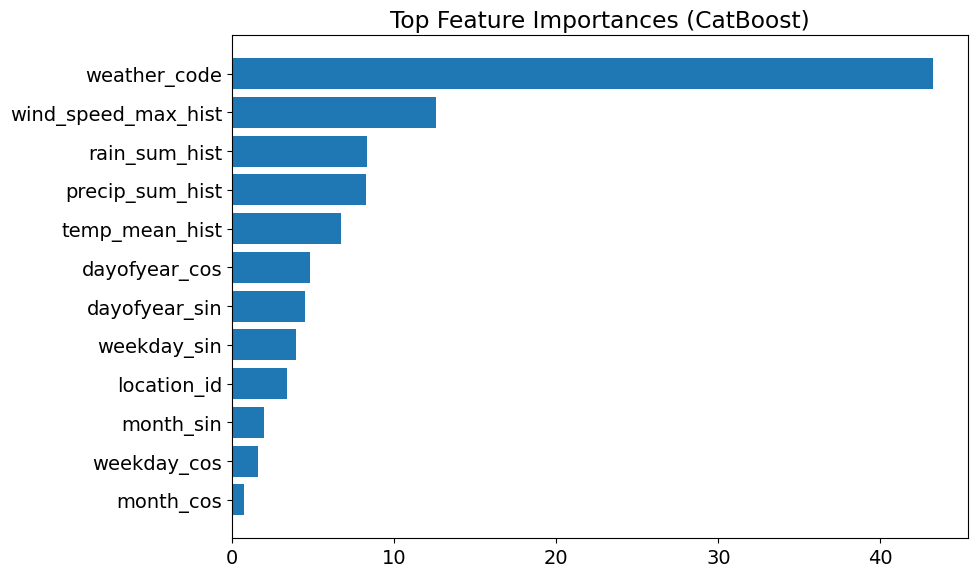

In [46]:
# Feature importance
importances = model.get_feature_importance(train_pool)
feat_imp = pd.DataFrame({"feature": features, "importance": importances})
feat_imp = feat_imp.sort_values(by="importance", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(feat_imp['feature'], feat_imp['importance'])
plt.gca().invert_yaxis()
plt.title("Top Feature Importances (CatBoost)")
plt.tight_layout()
plt.show()

# Hyperparameter tuning


In [49]:
def objective(trial):
    params = {
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, step=0.01),
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 5),
        'iterations': 1000,  # fixed iterations
        'loss_function': 'MultiRMSE',
        'random_seed': 42,
        'early_stopping_rounds': 50,
        'verbose': 0
    }

    model = CatBoostRegressor(**params)
    model.fit(train_pool, eval_set=val_pool, use_best_model=True)

    y_pred = model.predict(val_pool)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))
    return rmse


In [50]:
# Run hyperparameter optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)  # Increase n_trials for better tuning

print("Best Params:", study.best_params)

best_params = study.best_params

[I 2025-10-19 15:38:46,341] A new study created in memory with name: no-name-015f76c2-75ec-4c01-9827-c2f6e84275c9
[I 2025-10-19 15:39:38,242] Trial 0 finished with value: 4.186208824198266 and parameters: {'depth': 7, 'learning_rate': 0.09999999999999999, 'l2_leaf_reg': 2}. Best is trial 0 with value: 4.186208824198266.
[I 2025-10-19 15:40:48,467] Trial 1 finished with value: 4.194952570354836 and parameters: {'depth': 5, 'learning_rate': 0.09, 'l2_leaf_reg': 2}. Best is trial 0 with value: 4.186208824198266.
[I 2025-10-19 15:43:51,500] Trial 2 finished with value: 4.148206421187888 and parameters: {'depth': 7, 'learning_rate': 0.02, 'l2_leaf_reg': 1}. Best is trial 2 with value: 4.148206421187888.
[I 2025-10-19 15:46:41,995] Trial 3 finished with value: 4.224218264334378 and parameters: {'depth': 5, 'learning_rate': 0.02, 'l2_leaf_reg': 3}. Best is trial 2 with value: 4.148206421187888.
[I 2025-10-19 15:48:23,570] Trial 4 finished with value: 4.185358519073373 and parameters: {'depth'

Best Params: {'depth': 7, 'learning_rate': 0.08, 'l2_leaf_reg': 1}


In [51]:

# Train final model with best parameters
best_model = CatBoostRegressor(
    **best_params,
    iterations=1500,
    loss_function='MultiRMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100
)

best_model.fit(train_pool, eval_set=val_pool, use_best_model=True)


0:	learn: 15.2130424	test: 15.0415854	best: 15.0415854 (0)	total: 143ms	remaining: 3m 34s
100:	learn: 8.3763497	test: 8.4651254	best: 8.4567791 (99)	total: 13.4s	remaining: 3m 5s
200:	learn: 7.9937050	test: 8.3336527	best: 8.3321510 (199)	total: 28.6s	remaining: 3m 5s
300:	learn: 7.7372732	test: 8.2210825	best: 8.2210825 (300)	total: 47.8s	remaining: 3m 10s
400:	learn: 7.5603706	test: 8.2218375	best: 8.2031732 (359)	total: 1m 4s	remaining: 2m 57s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 8.203173177
bestIteration = 359

Shrink model to first 360 iterations.


In [60]:
# Validation
_ = evaluate(best_model, val_pool, y_val, "Validation")


Validation Performance
rain_sum → RMSE: 5.087, MAE: 2.054, R2: 0.734
precip_sum → RMSE: 5.087, MAE: 2.054, R2: 0.734
temp_mean → RMSE: 1.003, MAE: 0.784, R2: 0.817
wind_speed_max → RMSE: 3.813, MAE: 2.997, R2: 0.643


In [61]:
# Test
_ = evaluate(best_model, test_pool, y_test, "Test")


Test Performance
rain_sum → RMSE: 7.012, MAE: 3.231, R2: 0.640
precip_sum → RMSE: 7.012, MAE: 3.231, R2: 0.640
temp_mean → RMSE: 1.296, MAE: 1.014, R2: 0.754
wind_speed_max → RMSE: 3.495, MAE: 2.831, R2: 0.378


In [62]:

os.makedirs("../../models", exist_ok=True)
tuned_model_path_cbm = "./app/models/catboost_model.cbm"
best_model.save_model(tuned_model_path_cbm)

print(f"Trained tuned model saved to: {tuned_model_path_cbm}")


Trained tuned model saved to: ./app/models/catboost_model.cbm


In [66]:
def predict_future_batch(locations, dates, df, model, features, cat_features, y_targets):
    """
    Predict future weather for multiple locations and dates.

    Args:
        locations (list[int]): list of location_ids
        dates (list[str] or list[pd.Timestamp]): list of dates to predict
        df (pd.DataFrame): historical dataframe with *_hist features
        model (CatBoostRegressor): trained CatBoost MultiRMSE model
        features (list[str]): feature columns used for training
        cat_features (list[str]): categorical feature columns
        y_targets (list[str]): list of target columns

    Returns:
        pd.DataFrame: predictions with columns: location_id, date + targets
    """
    rows = []

    for loc, date_str in zip(locations, dates):
        date = pd.to_datetime(date_str)
        dayofyear = date.timetuple().tm_yday
        weekday = date.weekday()
        month = date.month

        # Most frequent historical weather code for that day of year
        subset = df[(df['location_id'] == loc) & (df['dayofyear'] == dayofyear)]
        if subset.empty:
            weather_code = df[df['location_id'] == loc]['weather_code'].mode()[0]
        else:
            weather_code = subset['weather_code'].mode()[0]

        # Construct row with features
        row = {
            'location_id': loc,
            'weather_code': weather_code,
            'month': month,
            'weekday': weekday,
            'dayofyear_sin': np.sin(2 * np.pi * dayofyear / 365),
            'dayofyear_cos': np.cos(2 * np.pi * dayofyear / 365),
            'month_sin': np.sin(2 * np.pi * month / 12),
            'month_cos': np.cos(2 * np.pi * month / 12),
            'weekday_sin': np.sin(2 * np.pi * weekday / 7),
            'weekday_cos': np.cos(2 * np.pi * weekday / 7)
        }


        # Add historical averages
        for target in y_targets:
            hist_value = subset[f'{target}_hist'].mean() if not subset.empty else df[df['location_id']==loc][f'{target}_hist'].mean()
            row[f'{target}_hist'] = hist_value

        rows.append(row)

    future_df = pd.DataFrame(rows)
    future_df = future_df[features].copy()  # avoid SettingWithCopyWarning

    # Ensure categorical features are properly typed
    for cat in cat_features:
        future_df[cat] = future_df[cat].astype('category')

    # Predict
    pool = Pool(future_df, cat_features=cat_features)
    preds = model.predict(pool)

    # Return DataFrame with predictions
    pred_df = pd.DataFrame(preds, columns=y_targets)
    pred_df.insert(0, 'date', dates)
    pred_df.insert(0, 'location_id', locations)
    return pred_df


In [67]:
# Predict for multiple locations and dates
locations = [5, 10, 3]
dates = ["2026-01-01", "2026-01-01", "2026-01-01"]

future_predictions = predict_future_batch(locations, dates, df, best_model, features, cat_features, y_targets)
print(future_predictions)


   location_id        date  rain_sum  precip_sum  temp_mean  wind_speed_max
0            5  2026-01-01  3.095136    3.095136  15.968520        9.773180
1           10  2026-01-01  0.992877    0.992877  25.476492       18.710880
2            3  2026-01-01  1.018575    1.018575  22.376321       14.713196
